# Backpropagation for an MLP

## Real-World Scenario: Classifying Bacterial Antibiotic Resistance from Genomic Features

A microbiology lab wants to classify bacterial isolates into **three resistance profiles** — susceptible, intermediate, or resistant — based on genomic features extracted from whole-genome sequencing. We build a **one-hidden-layer MLP entirely from scratch** in NumPy, implementing forward propagation, cross-entropy loss, and backpropagation by hand, following Exercise 13.1 from PML Chapter 13.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Key Formulas from PML Chapter 13 (Exercise 13.1)

**MLP architecture** — one hidden layer with ReLU activation and softmax output:

$$\mathbf{z} = W\mathbf{x} + \mathbf{b}_1 \in \mathbb{R}^K \qquad \text{(pre-activation, Eq. 13.112)}$$

$$\mathbf{h} = \text{ReLU}(\mathbf{z}) \in \mathbb{R}^K \qquad \text{(hidden layer, Eq. 13.113)}$$

$$\mathbf{a} = U\mathbf{h} + \mathbf{b}_2 \in \mathbb{R}^C \qquad \text{(logits, Eq. 13.114)}$$

$$\mathcal{L} = \text{CrossEntropy}(\mathbf{y},\, \text{softmax}(\mathbf{a})) \in \mathbb{R} \qquad \text{(Eq. 13.115)}$$

where $D$ = input dimension, $K$ = hidden units, $C$ = number of classes.

**Backpropagation gradients:**

| Gradient | Formula | Shape |
|---|---|---|
| $\boldsymbol{\delta}_1 = \nabla_{\mathbf{a}} \mathcal{L}$ | $\mathbf{p} - \mathbf{y}$ | $\mathbb{R}^C$ |
| $\nabla_U \mathcal{L}$ | $\boldsymbol{\delta}_1 \mathbf{h}^\top$ | $\mathbb{R}^{C \times K}$ |
| $\nabla_{\mathbf{b}_2} \mathcal{L}$ | $\boldsymbol{\delta}_1$ | $\mathbb{R}^C$ |
| $\boldsymbol{\delta}_2 = \nabla_{\mathbf{z}} \mathcal{L}$ | $(U^\top \boldsymbol{\delta}_1) \odot H(\mathbf{z})$ | $\mathbb{R}^K$ |
| $\nabla_W \mathcal{L}$ | $\boldsymbol{\delta}_2 \mathbf{x}^\top$ | $\mathbb{R}^{K \times D}$ |
| $\nabla_{\mathbf{b}_1} \mathcal{L}$ | $\boldsymbol{\delta}_2$ | $\mathbb{R}^K$ |

where $\mathbf{p} = \text{softmax}(\mathbf{a})$, $\mathbf{y}$ is the one-hot target, and $H$ is the Heaviside step function.

## 1. Generate Synthetic Genomic Data

We simulate $D = 5$ genomic features (e.g., counts of resistance-associated SNPs in different gene clusters) for $N = 600$ bacterial isolates across $C = 3$ resistance classes.

In [2]:
D = 5   # input features (genomic markers)
C = 3   # classes: susceptible, intermediate, resistant
N = 600

# Class centers in feature space (each class has a distinct genomic signature)
mu = {
    0: np.array([-1.0, -0.5,  0.3, -0.8,  0.2]),   # susceptible
    1: np.array([ 0.5,  0.8, -0.4,  0.3,  0.7]),   # intermediate
    2: np.array([ 1.2, -0.3,  1.0,  1.0, -0.5]),   # resistant
}

X_list, y_list = [], []
for c in range(C):
    Xc = mu[c] + 0.9 * np.random.randn(N // C, D)
    X_list.append(Xc)
    y_list.append(np.full(N // C, c, dtype=int))

X_all = np.vstack(X_list)
y_all = np.concatenate(y_list)

# Shuffle
perm = np.random.permutation(N)
X_all, y_all = X_all[perm], y_all[perm]

# Train / test split (80/20)
N_train = int(0.8 * N)
X_train, y_train = X_all[:N_train], y_all[:N_train]
X_test, y_test = X_all[N_train:], y_all[N_train:]

print(f"Training: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")
print(f"Features D={D}, Classes C={C}")
print(f"Class distribution (train): {np.bincount(y_train)}")

Training: 480 samples, Test: 120 samples
Features D=5, Classes C=3
Class distribution (train): [163 163 154]


## 2. Building Blocks from Scratch

We implement each layer of the MLP as a standalone function, then derive and implement its gradient. This follows the modular approach of Algorithm 13.3 (backprop for an MLP with $K$ layers).

### 2.1 Softmax (Eq. 13.38)

The softmax converts raw logits $\mathbf{a} \in \mathbb{R}^C$ into a probability distribution:

$$p_c = \text{softmax}(\mathbf{a})_c = \frac{e^{a_c}}{\sum_{j=1}^{C} e^{a_j}}$$

For numerical stability we subtract $\max(\mathbf{a})$ before exponentiating — this doesn't change the result because $\frac{e^{a_c - m}}{\sum_j e^{a_j - m}} = \frac{e^{a_c}}{\sum_j e^{a_j}}$.

In [3]:
def softmax(a):
    """Numerically stable softmax.
    a: (C,) logits for one sample, or (N, C) for a batch.
    Returns same shape as input.
    """
    shifted = a - np.max(a, axis=-1, keepdims=True)
    exp_a = np.exp(shifted)
    return exp_a / np.sum(exp_a, axis=-1, keepdims=True)


# Quick test
a_test = np.array([2.0, 1.0, 0.1])
p_test = softmax(a_test)
print(f"Logits:       {a_test}")
print(f"Softmax:      {p_test}")
print(f"Sum to 1?     {p_test.sum():.6f}")

Logits:       [2.  1.  0.1]
Softmax:      [0.65900114 0.24243297 0.09856589]
Sum to 1?     1.000000


### 2.2 Cross-Entropy Loss (Eq. 13.38)

For a one-hot target $\mathbf{y}$ and predicted probabilities $\mathbf{p} = \text{softmax}(\mathbf{a})$:

$$\mathcal{L} = -\sum_{c=1}^{C} y_c \log p_c$$

Since $\mathbf{y}$ is one-hot with $y_c = 1$ only for the true class $c^*$, this simplifies to $\mathcal{L} = -\log p_{c^*}$.

In [4]:
def cross_entropy_loss(logits, y_onehot):
    """Cross-entropy loss from logits (numerically stable).
    logits: (N, C), y_onehot: (N, C) one-hot.
    Returns scalar average loss.
    """
    # Log-sum-exp trick for log(softmax)
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    log_sum_exp = np.log(np.sum(np.exp(shifted), axis=1, keepdims=True))
    log_probs = shifted - log_sum_exp  # log(softmax(a))
    # -sum(y * log(p)) per sample, averaged over batch
    return -np.mean(np.sum(y_onehot * log_probs, axis=1))

### 2.3 ReLU Activation (Eq. 13.44–13.46)

$$\text{ReLU}(a) = \max(a, 0) \qquad \Longrightarrow \qquad \text{ReLU}'(a) = H(a) = \begin{cases} 1 & a > 0 \\ 0 & a \le 0 \end{cases}$$

The Jacobian of an elementwise nonlinearity is diagonal (Eq. 13.43): $J = \text{diag}(\varphi'(\mathbf{z}))$. The VJP $\mathbf{u}^\top J$ reduces to elementwise multiplication $\mathbf{u} \odot H(\mathbf{z})$.

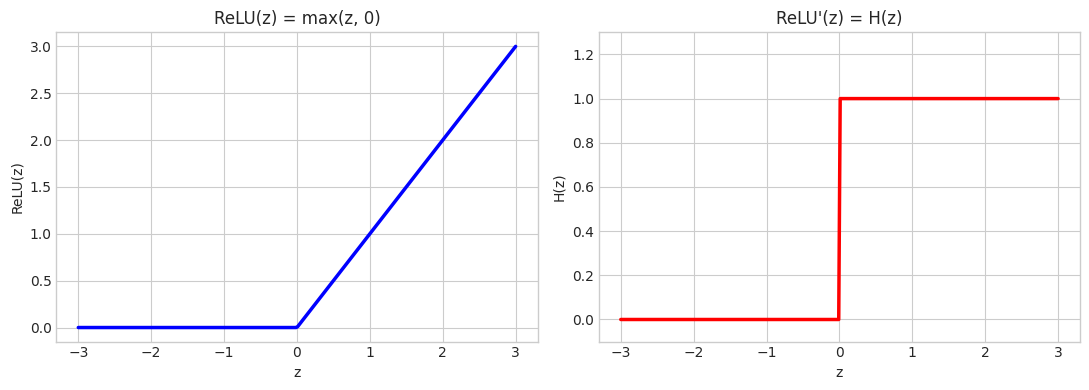

In [5]:
def relu(z):
    return np.maximum(z, 0.0)

def relu_derivative(z):
    """Heaviside step function H(z): derivative of ReLU."""
    return (z > 0).astype(float)


# Visualize ReLU and its derivative
z_vis = np.linspace(-3, 3, 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(z_vis, relu(z_vis), 'b-', lw=2.5)
axes[0].set_title('ReLU(z) = max(z, 0)')
axes[0].set_xlabel('z'); axes[0].set_ylabel('ReLU(z)')

axes[1].plot(z_vis, relu_derivative(z_vis), 'r-', lw=2.5)
axes[1].set_title("ReLU'(z) = H(z)")
axes[1].set_xlabel('z'); axes[1].set_ylabel('H(z)')
axes[1].set_ylim(-0.1, 1.3)

plt.tight_layout()
plt.show()

## 3. Forward Pass

The complete forward pass for a single sample $\mathbf{x} \in \mathbb{R}^D$:

$$\mathbf{x} \xrightarrow{W, \mathbf{b}_1} \mathbf{z} \xrightarrow{\text{ReLU}} \mathbf{h} \xrightarrow{U, \mathbf{b}_2} \mathbf{a} \xrightarrow{\text{softmax}} \mathbf{p} \xrightarrow{\text{CE}(\mathbf{y}, \cdot)} \mathcal{L}$$

We store the **pre-activations** $\mathbf{z}$ (needed for $H(\mathbf{z})$ in backprop) and the **hidden activations** $\mathbf{h}$ (needed for $\nabla_U \mathcal{L} = \boldsymbol{\delta}_1 \mathbf{h}^\top$).

In [16]:
def forward(X, W, b1, U, b2):
    """Forward pass for a batch of N samples.
    X:  (N, D)
    W:  (K, D), b1: (K,)
    U:  (C, K), b2: (C,)
    Returns (logits, cache) where cache stores intermediates for backprop.
    """
    z = X @ W.T + b1           # (N, K)  pre-activations  (Eq. 13.112)
    h = relu(z)                # (N, K)  hidden layer      (Eq. 13.113)
    a = h @ U.T + b2           # (N, C)  logits            (Eq. 13.114)
    cache = (X, z, h, a)
    return a, cache


# One-hot encoding helper
def one_hot(y, C):
    Y = np.zeros((len(y), C))
    Y[np.arange(len(y)), y] = 1.0
    return Y

Y_train = one_hot(y_train, C)
Y_test = one_hot(y_test, C)

Y_test[:5]

array([[0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.]])

## 4. Backward Pass — Deriving Every Gradient

This is the core of Exercise 13.1. We derive each gradient step by step using the chain rule, proceeding backward from the loss to the input.

### Step 1: Gradient of loss w.r.t. logits — $\boldsymbol{\delta}_1$ (Eq. 13.121)

The cross-entropy + softmax layer has an elegantly simple combined gradient (Eq. 13.39):

$$\boldsymbol{\delta}_1 = \nabla_{\mathbf{a}} \mathcal{L} = \mathbf{p} - \mathbf{y}$$

**Derivation:** Since $\mathcal{L} = -\log p_{c^*}$ and $p_c = \text{softmax}(\mathbf{a})_c$, the partial derivative is (Eq. 13.41):

$$\frac{\partial \mathcal{L}}{\partial a_i} = p_i - \mathbb{1}[i = c^*]$$

This is $\mathbf{p} - \mathbf{y}$ when $\mathbf{y}$ is one-hot.

### Step 2: Gradients for output layer — $\nabla_U \mathcal{L}$ and $\nabla_{\mathbf{b}_2} \mathcal{L}$ (Eq. 13.116–13.117)

The logit layer is $\mathbf{a} = U\mathbf{h} + \mathbf{b}_2$ — a linear layer. From Section 13.3.3.3 (Eq. 13.55):

$$\nabla_U \mathcal{L} = \boldsymbol{\delta}_1 \mathbf{h}^\top \in \mathbb{R}^{C \times K} \qquad \nabla_{\mathbf{b}_2} \mathcal{L} = \boldsymbol{\delta}_1 \in \mathbb{R}^C$$

### Step 3: Backpropagate through the linear layer to get $\nabla_{\mathbf{h}} \mathcal{L}$

Using the VJP for a linear layer (Eq. 13.50), we propagate the gradient through $U$:

$$\nabla_{\mathbf{h}} \mathcal{L} = U^\top \boldsymbol{\delta}_1 \in \mathbb{R}^K$$

### Step 4: Backpropagate through ReLU — $\boldsymbol{\delta}_2$ (Eq. 13.122)

The ReLU Jacobian is diagonal: $J = \text{diag}(H(\mathbf{z}))$ (Eq. 13.43, 13.46). The VJP is elementwise multiplication:

$$\boldsymbol{\delta}_2 = \nabla_{\mathbf{z}} \mathcal{L} = (U^\top \boldsymbol{\delta}_1) \odot H(\mathbf{z}) \in \mathbb{R}^K$$

This is why we stored the pre-activations $\mathbf{z}$: we need $H(\mathbf{z})$ to know which neurons were active.

### Step 5: Gradients for hidden layer — $\nabla_W \mathcal{L}$ and $\nabla_{\mathbf{b}_1} \mathcal{L}$ (Eq. 13.118–13.119)

Identical structure to Step 2, but one layer earlier:

$$\nabla_W \mathcal{L} = \boldsymbol{\delta}_2 \mathbf{x}^\top \in \mathbb{R}^{K \times D} \qquad \nabla_{\mathbf{b}_1} \mathcal{L} = \boldsymbol{\delta}_2 \in \mathbb{R}^K$$

In [7]:
def backward(Y_onehot, W, U, cache):
    """Backward pass for a batch of N samples.
    Y_onehot: (N, C) one-hot targets
    Returns dict of gradients for W, b1, U, b2.
    """
    X, z, h, a = cache
    N = X.shape[0]
    p = softmax(a)                        # (N, C)

    # Step 1: delta_1 = p - y  (Eq. 13.121)
    delta1 = (p - Y_onehot) / N           # (N, C), average over batch

    # Step 2: output layer gradients (Eq. 13.116, 13.117)
    grad_U  = delta1.T @ h                # (C, K) = (C,N) @ (N,K)
    grad_b2 = delta1.sum(axis=0)          # (C,)

    # Step 3: backprop through linear layer (Eq. 13.50)
    grad_h = delta1 @ U                   # (N, K) = (N,C) @ (C,K)

    # Step 4: backprop through ReLU (Eq. 13.122)
    delta2 = grad_h * relu_derivative(z)  # (N, K) elementwise

    # Step 5: hidden layer gradients (Eq. 13.118, 13.119)
    grad_W  = delta2.T @ X                # (K, D) = (K,N) @ (N,D)
    grad_b1 = delta2.sum(axis=0)          # (K,)

    return {'W': grad_W, 'b1': grad_b1, 'U': grad_U, 'b2': grad_b2}

## 5. Gradient Check — Numerical Verification

Before training, we verify our analytic gradients against **finite differences**. For each parameter $\theta_i$:

$$\frac{\partial \mathcal{L}}{\partial \theta_i} \approx \frac{\mathcal{L}(\theta_i + \epsilon) - \mathcal{L}(\theta_i - \epsilon)}{2\epsilon}$$

If the relative error between analytic and numerical gradients is below $10^{-5}$, our backprop is correct.

In [8]:
def numerical_gradient(f, param, eps=1e-5):
    """Central-difference gradient for an arbitrary parameter array."""
    grad = np.zeros_like(param)
    it = np.nditer(param, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        old_val = param[idx]

        param[idx] = old_val + eps
        loss_plus = f()
        param[idx] = old_val - eps
        loss_minus = f()
        param[idx] = old_val  # restore

        grad[idx] = (loss_plus - loss_minus) / (2 * eps)
        it.iternext()
    return grad


# Initialize small network for gradient checking
K_check = 4
np.random.seed(0)
W_c  = np.random.randn(K_check, D) * 0.1
b1_c = np.zeros(K_check)
U_c  = np.random.randn(C, K_check) * 0.1
b2_c = np.zeros(C)

# Use a small subset
X_sub, Y_sub = X_train[:20], Y_train[:20]

def loss_fn():
    logits, _ = forward(X_sub, W_c, b1_c, U_c, b2_c)
    return cross_entropy_loss(logits, Y_sub)

# Analytic gradients
logits_c, cache_c = forward(X_sub, W_c, b1_c, U_c, b2_c)
grads = backward(Y_sub, W_c, U_c, cache_c)

# Compare each parameter
for name, param, grad_analytic in [
    ('W',  W_c,  grads['W']),
    ('b1', b1_c, grads['b1']),
    ('U',  U_c,  grads['U']),
    ('b2', b2_c, grads['b2']),
]:
    grad_num = numerical_gradient(loss_fn, param)
    diff = np.max(np.abs(grad_analytic - grad_num))
    rel = diff / (np.max(np.abs(grad_num)) + 1e-12)
    status = "PASS" if rel < 1e-5 else "FAIL"
    print(f"{name:>3s}  max|diff|={diff:.2e}  rel_err={rel:.2e}  [{status}]")

  W  max|diff|=2.25e-11  rel_err=3.49e-10  [PASS]
 b1  max|diff|=1.10e-11  rel_err=3.28e-10  [PASS]
  U  max|diff|=1.70e-11  rel_err=1.79e-10  [PASS]
 b2  max|diff|=1.60e-11  rel_err=2.87e-10  [PASS]


## 6. Training with Mini-Batch SGD

We train the MLP using stochastic gradient descent (Section 8.4). At each iteration we sample a mini-batch, compute the forward pass, backpropagate the gradients, and update:

$$\theta_{t+1} = \theta_t - \eta \, \nabla_\theta \mathcal{L}$$

We use **He initialization** for the weights: $W_{ij} \sim \mathcal{N}(0, 2/\text{fan\_in})$, which accounts for the fact that ReLU kills half the units on average.

In [9]:
def predict(X, W, b1, U, b2):
    logits, _ = forward(X, W, b1, U, b2)
    return np.argmax(logits, axis=1)

def accuracy(X, y, W, b1, U, b2):
    return np.mean(predict(X, W, b1, U, b2) == y)


# Hyperparameters
K = 32             # hidden units
lr = 0.1           # learning rate
epochs = 200
batch_size = 64

# He initialization
np.random.seed(42)
W  = np.random.randn(K, D) * np.sqrt(2.0 / D)
b1 = np.zeros(K)
U  = np.random.randn(C, K) * np.sqrt(2.0 / K)
b2 = np.zeros(C)

# Training loop
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(epochs):
    # Shuffle training data each epoch
    perm = np.random.permutation(N_train)
    X_shuf, Y_shuf = X_train[perm], Y_train[perm]

    for i in range(0, N_train, batch_size):
        Xb = X_shuf[i:i+batch_size]
        Yb = Y_shuf[i:i+batch_size]

        # Forward
        logits, cache = forward(Xb, W, b1, U, b2)

        # Backward
        grads = backward(Yb, W, U, cache)

        # SGD update
        W  -= lr * grads['W']
        b1 -= lr * grads['b1']
        U  -= lr * grads['U']
        b2 -= lr * grads['b2']

    # Track metrics
    logits_tr, _ = forward(X_train, W, b1, U, b2)
    logits_te, _ = forward(X_test, W, b1, U, b2)
    train_losses.append(cross_entropy_loss(logits_tr, Y_train))
    test_losses.append(cross_entropy_loss(logits_te, Y_test))
    train_accs.append(accuracy(X_train, y_train, W, b1, U, b2))
    test_accs.append(accuracy(X_test, y_test, W, b1, U, b2))

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}  |  loss: {train_losses[-1]:.4f}  "
              f"acc: {train_accs[-1]:.3f}  |  test_acc: {test_accs[-1]:.3f}")

Epoch  50  |  loss: 0.2955  acc: 0.881  |  test_acc: 0.892
Epoch 100  |  loss: 0.2817  acc: 0.885  |  test_acc: 0.908
Epoch 150  |  loss: 0.2721  acc: 0.887  |  test_acc: 0.908
Epoch 200  |  loss: 0.2627  acc: 0.892  |  test_acc: 0.892


## 7. Training Curves

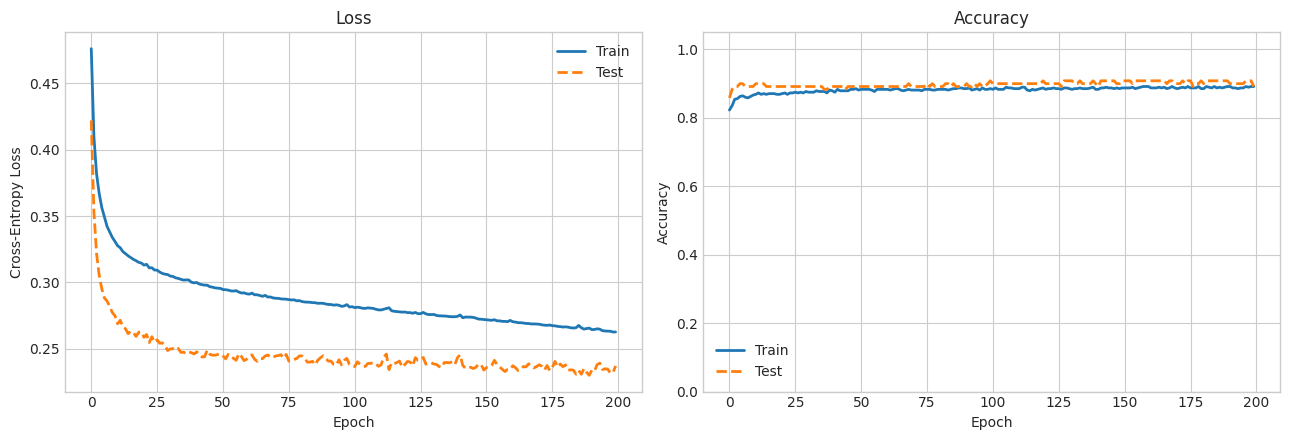

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(train_losses, label='Train', lw=2)
axes[0].plot(test_losses, label='Test', lw=2, ls='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(train_accs, label='Train', lw=2)
axes[1].plot(test_accs, label='Test', lw=2, ls='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy'); axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 8. Visualizing the Decision Boundary

To visualize the learned nonlinear decision regions (cf. Figure 13.3 from the textbook), we project the $D=5$ features down to the first two principal components and plot the MLP's predictions across the 2D plane.

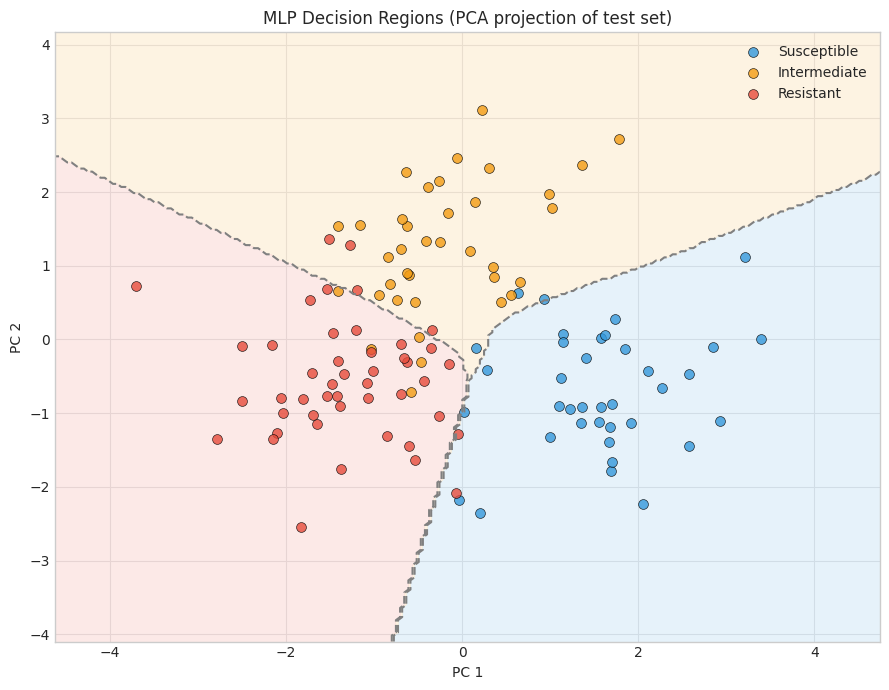

In [11]:
# Simple PCA via SVD for 2D projection
X_mean = X_train.mean(axis=0)
X_centered = X_train - X_mean
_, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
V2 = Vt[:2]  # top 2 principal components

X_train_2d = (X_train - X_mean) @ V2.T
X_test_2d  = (X_test - X_mean)  @ V2.T

# Create mesh over PCA space
margin = 0.5
x_min, x_max = X_train_2d[:, 0].min() - margin, X_train_2d[:, 0].max() + margin
y_min, y_max = X_train_2d[:, 1].min() - margin, X_train_2d[:, 1].max() + margin
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))
grid_2d = np.c_[xx.ravel(), yy.ravel()]

# Reconstruct approximate D-dimensional input from 2D projection
grid_Dd = grid_2d @ V2 + X_mean  # (n_grid, D)

# Predict on the grid
grid_preds = predict(grid_Dd, W, b1, U, b2).reshape(xx.shape)

# Plot
class_names = ['Susceptible', 'Intermediate', 'Resistant']
colors = ['#3498db', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(xx, yy, grid_preds, levels=[-0.5, 0.5, 1.5, 2.5],
            colors=['#d6eaf8', '#fdebd0', '#fadbd8'], alpha=0.6)
ax.contour(xx, yy, grid_preds, levels=[0.5, 1.5], colors='gray', linewidths=1.5, linestyles='--')

for c in range(C):
    mask = y_test == c
    ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
               c=colors[c], edgecolors='k', s=50, label=class_names[c], alpha=0.8, linewidths=0.5)

ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title('MLP Decision Regions (PCA projection of test set)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 9. Visualizing Hidden Unit Activations

Each hidden unit $h_k = \text{ReLU}(W_k^\top \mathbf{x} + b_{1,k})$ acts as a learned feature detector. ReLU creates piecewise-linear decision regions (cf. Figure 13.7 from the textbook). Let's see what the hidden layer has learned.

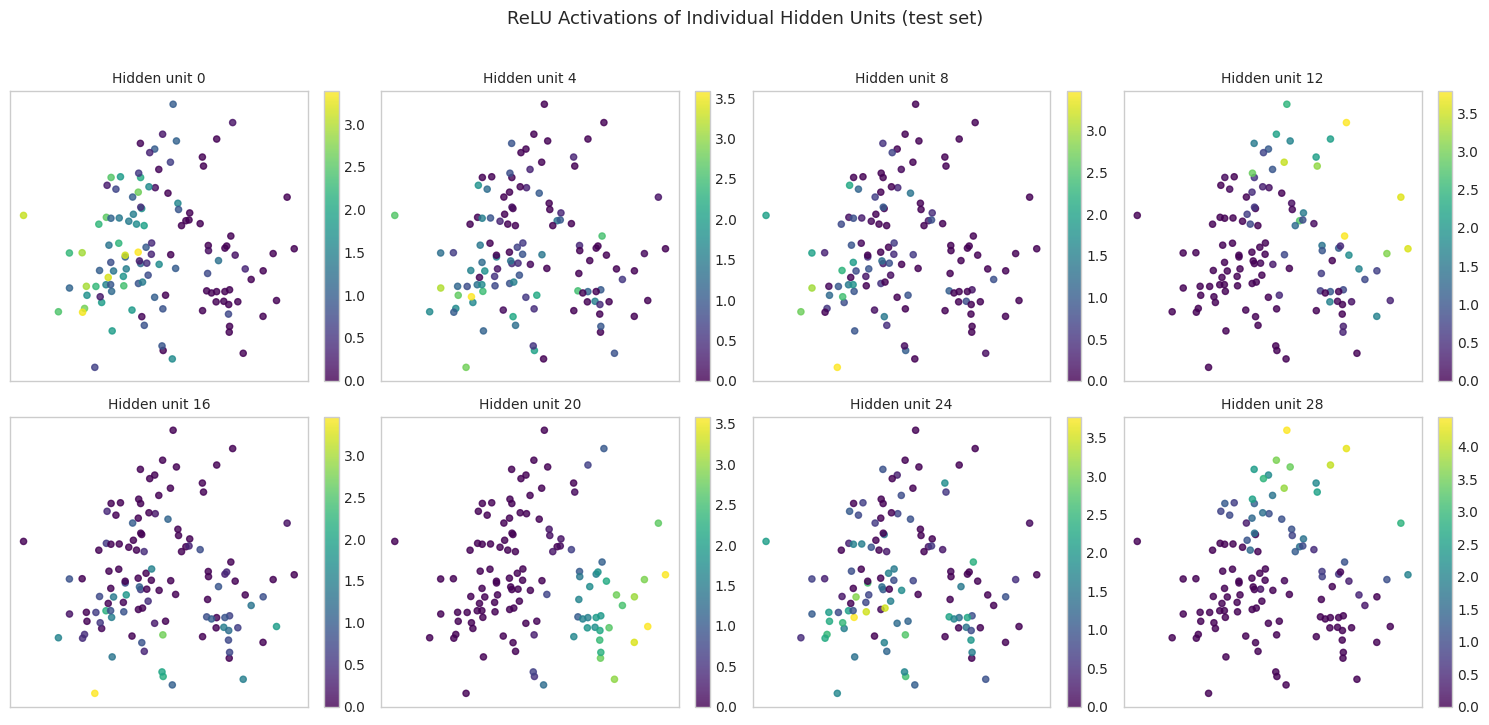

Dead units (always zero on test set): 0.0%


In [12]:
# Compute hidden activations for test set
_, cache_vis = forward(X_test, W, b1, U, b2)
_, _, h_test, _ = cache_vis

# Show activation patterns for 8 selected hidden units
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for idx, ax in enumerate(axes.flat):
    k = idx * (K // 8)  # sample evenly across hidden units
    sc = ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                    c=h_test[:, k], cmap='viridis', s=20, alpha=0.8)
    ax.set_title(f'Hidden unit {k}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(sc, ax=ax, fraction=0.046)

fig.suptitle('ReLU Activations of Individual Hidden Units (test set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# What fraction of hidden units are "dead" (always zero)?
dead_fraction = np.mean(h_test.max(axis=0) == 0)
print(f"Dead units (always zero on test set): {dead_fraction:.1%}")

## 10. Confusion Matrix and Per-Class Probabilities

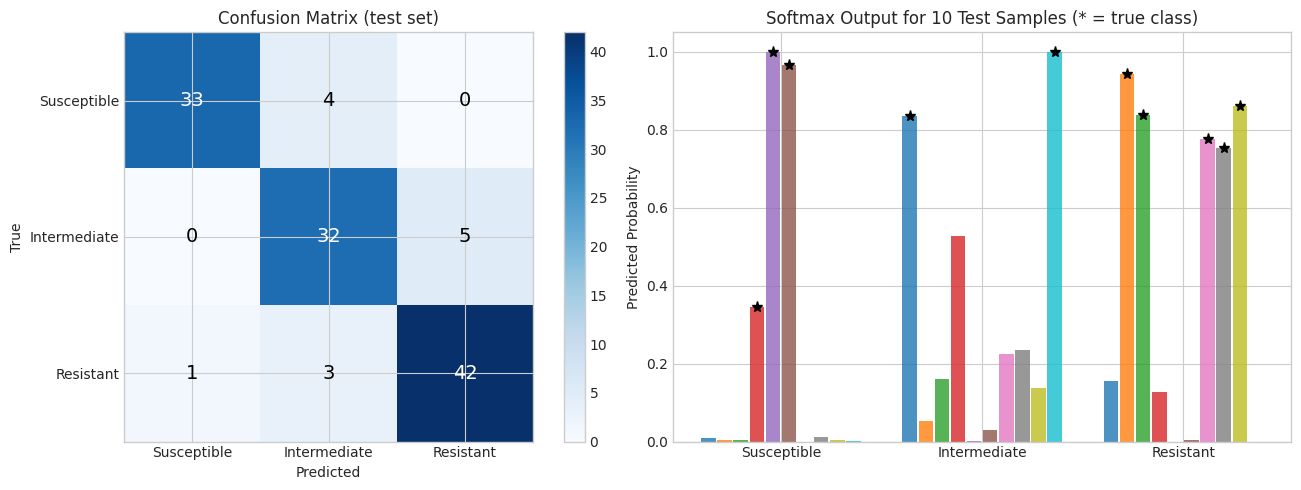


Final test accuracy: 89.2%


In [13]:
# Confusion matrix
y_pred_test = predict(X_test, W, b1, U, b2)
conf = np.zeros((C, C), dtype=int)
for true, pred in zip(y_test, y_pred_test):
    conf[true, pred] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: confusion matrix
im = axes[0].imshow(conf, cmap='Blues')
for i in range(C):
    for j in range(C):
        axes[0].text(j, i, str(conf[i, j]), ha='center', va='center',
                     fontsize=14, color='white' if conf[i, j] > conf.max()/2 else 'black')
axes[0].set_xticks(range(C)); axes[0].set_yticks(range(C))
axes[0].set_xticklabels(class_names, fontsize=10)
axes[0].set_yticklabels(class_names, fontsize=10)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (test set)')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Right: predicted probability distribution for a few test samples
logits_te, _ = forward(X_test[:10], W, b1, U, b2)
probs_te = softmax(logits_te)
x_pos = np.arange(C)
width = 0.08
for i in range(10):
    axes[1].bar(x_pos + i * width, probs_te[i], width=width * 0.9, alpha=0.8)
    # Mark true class
    true_c = y_test[i]
    axes[1].plot(x_pos[true_c] + i * width, probs_te[i, true_c], 'k*', markersize=8)

axes[1].set_xticks(x_pos + 4.5 * width)
axes[1].set_xticklabels(class_names, fontsize=10)
axes[1].set_ylabel('Predicted Probability')
axes[1].set_title('Softmax Output for 10 Test Samples (* = true class)')

plt.tight_layout()
plt.show()

print(f"\nFinal test accuracy: {accuracy(X_test, y_test, W, b1, U, b2):.1%}")

## 11. Gradient Flow Visualization

A key insight from Section 13.4 is that gradients must flow backward through the entire network. ReLU's derivative is either 0 or 1, so gradients pass through unchanged for active units but are completely blocked for inactive ones. Let's visualize the magnitude of $\boldsymbol{\delta}_1$ and $\boldsymbol{\delta}_2$ across a batch to see how the signal propagates.

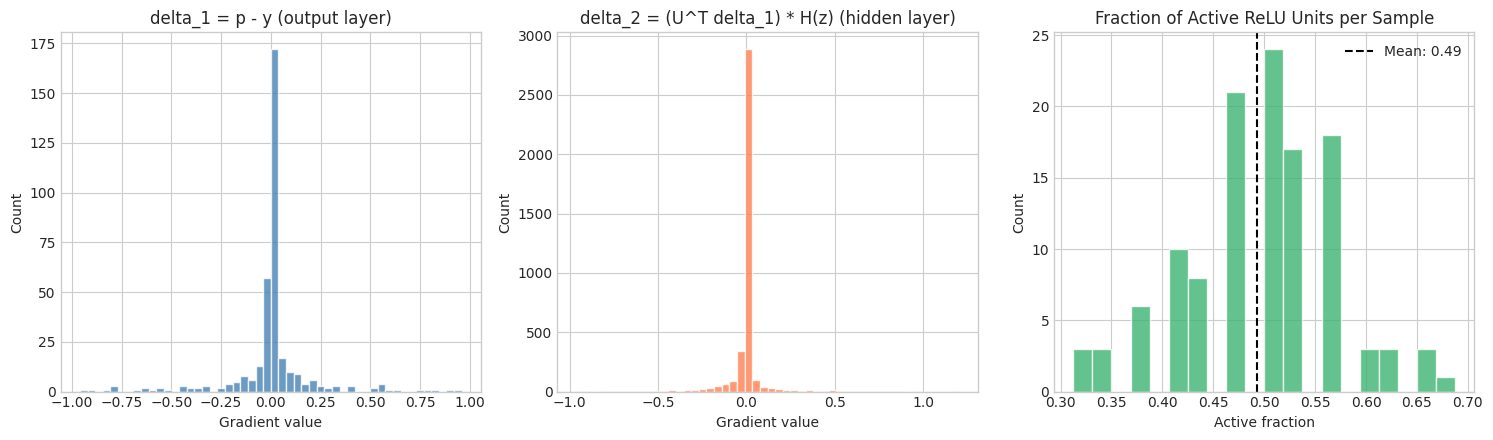

In [14]:
# Compute deltas for the full test set
logits_te, cache_te = forward(X_test, W, b1, U, b2)
X_c, z_c, h_c, a_c = cache_te
p_c = softmax(a_c)

delta1 = p_c - Y_test                                # (N_test, C)
grad_h = delta1 @ U                                  # (N_test, K)
delta2 = grad_h * relu_derivative(z_c)               # (N_test, K)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(delta1.ravel(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('delta_1 = p - y (output layer)')
axes[0].set_xlabel('Gradient value'); axes[0].set_ylabel('Count')

axes[1].hist(delta2.ravel(), bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('delta_2 = (U^T delta_1) * H(z) (hidden layer)')
axes[1].set_xlabel('Gradient value'); axes[1].set_ylabel('Count')

# Fraction of active (non-zero gradient) units per sample
active_frac = (z_c > 0).mean(axis=1)
axes[2].hist(active_frac, bins=20, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[2].set_title('Fraction of Active ReLU Units per Sample')
axes[2].set_xlabel('Active fraction'); axes[2].set_ylabel('Count')
axes[2].axvline(active_frac.mean(), color='k', ls='--', label=f'Mean: {active_frac.mean():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()

In [20]:
(z_c > 0)
active_frac

array([0.40625, 0.375  , 0.3125 , 0.5625 , 0.4375 , 0.375  , 0.5    ,
       0.46875, 0.5    , 0.46875, 0.5    , 0.375  , 0.4375 , 0.5    ,
       0.53125, 0.46875, 0.5    , 0.40625, 0.3125 , 0.40625, 0.5625 ,
       0.53125, 0.53125, 0.5    , 0.46875, 0.53125, 0.6875 , 0.5    ,
       0.5    , 0.34375, 0.46875, 0.5625 , 0.53125, 0.59375, 0.46875,
       0.625  , 0.5625 , 0.5    , 0.34375, 0.5625 , 0.46875, 0.53125,
       0.53125, 0.5    , 0.46875, 0.34375, 0.5625 , 0.5625 , 0.5625 ,
       0.46875, 0.65625, 0.46875, 0.625  , 0.53125, 0.4375 , 0.46875,
       0.53125, 0.5    , 0.53125, 0.5    , 0.40625, 0.4375 , 0.5    ,
       0.5    , 0.65625, 0.40625, 0.46875, 0.5    , 0.5625 , 0.5    ,
       0.5625 , 0.4375 , 0.46875, 0.65625, 0.5625 , 0.46875, 0.46875,
       0.59375, 0.5    , 0.5625 , 0.5    , 0.5625 , 0.4375 , 0.40625,
       0.40625, 0.5625 , 0.46875, 0.53125, 0.40625, 0.5625 , 0.4375 ,
       0.59375, 0.5    , 0.3125 , 0.375  , 0.53125, 0.4375 , 0.5625 ,
       0.53125, 0.5 

## 12. Weight Matrices Visualization

The learned weight matrix $W \in \mathbb{R}^{K \times D}$ maps each of the $D$ genomic features to the $K$ hidden units. Each row of $W$ is a "template" in feature space. The output matrix $U \in \mathbb{R}^{C \times K}$ then maps the hidden representation to class logits.

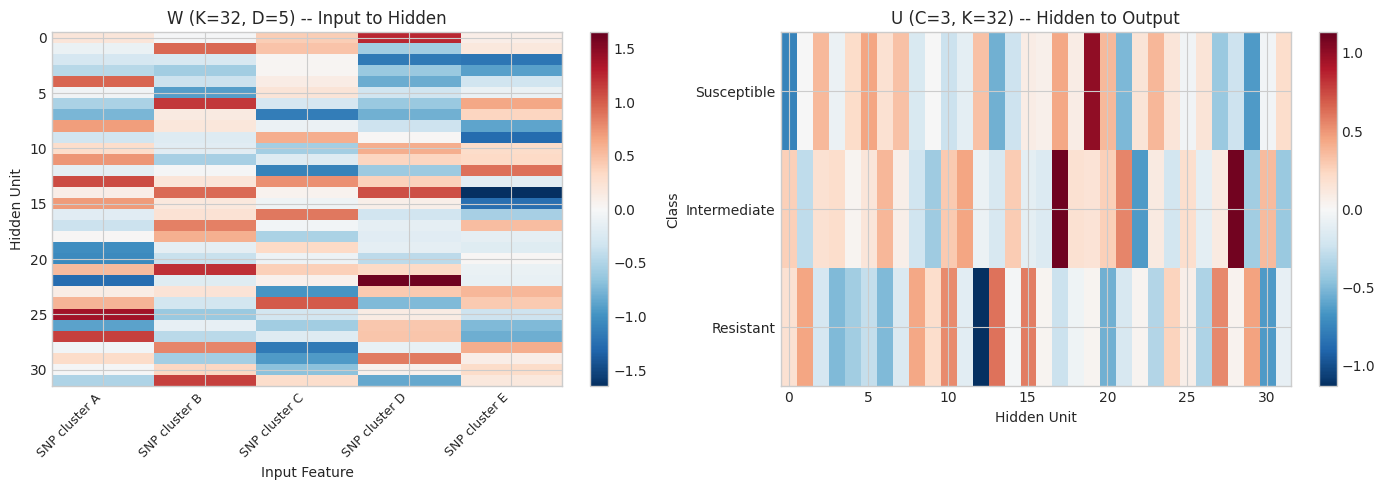

Total parameters: 291
  W: 32x5 = 160,  b1: 32
  U: 3x32 = 96,  b2: 3


In [15]:
feature_names = ['SNP cluster A', 'SNP cluster B', 'SNP cluster C', 'SNP cluster D', 'SNP cluster E']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# W: (K, D)
im0 = axes[0].imshow(W, aspect='auto', cmap='RdBu_r', vmin=-np.abs(W).max(), vmax=np.abs(W).max())
axes[0].set_xlabel('Input Feature'); axes[0].set_ylabel('Hidden Unit')
axes[0].set_xticks(range(D)); axes[0].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=9)
axes[0].set_title(f'W (K={K}, D={D}) -- Input to Hidden')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# U: (C, K)
im1 = axes[1].imshow(U, aspect='auto', cmap='RdBu_r', vmin=-np.abs(U).max(), vmax=np.abs(U).max())
axes[1].set_xlabel('Hidden Unit'); axes[1].set_ylabel('Class')
axes[1].set_yticks(range(C)); axes[1].set_yticklabels(class_names, fontsize=10)
axes[1].set_title(f'U (C={C}, K={K}) -- Hidden to Output')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

# Parameter count summary
n_params = W.size + b1.size + U.size + b2.size
print(f"Total parameters: {n_params}")
print(f"  W: {K}x{D} = {W.size},  b1: {b1.size}")
print(f"  U: {C}x{K} = {U.size},  b2: {b2.size}")